<a href="https://colab.research.google.com/github/RiccoFlores/100-Days-Of-ML-Code/blob/master/NB4_5_Text_Classification_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB4.5 Text Classification with Sentiment Analysis

This notebook develops a text classification workflow for sentiment analysis. The task is to identify whether a movie review expresses a negative or positive opinion.

The workflow begins with a classical machine learning baseline and then moves to a neural network with an Embedding layer and an LSTM layer. Both models are evaluated with the same test set.

## 1. Environment setup

The notebook uses TensorFlow Datasets to download the IMDB Reviews dataset, scikit-learn for the baseline model and evaluation metrics, and TensorFlow to build the neural network.

In [1]:
!pip -q install tensorflow-datasets scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

## 2. Load the dataset

The IMDB Reviews dataset contains movie reviews labeled as negative or positive. Label 0 represents a negative review and label 1 represents a positive review.

A subset is used to keep the execution time reasonable during class.

In [ ]:
train_ds = tfds.load("imdb_reviews", split="train[:10000]", as_supervised=True)
valid_ds = tfds.load("imdb_reviews", split="train[10000:12000]", as_supervised=True)
test_ds = tfds.load("imdb_reviews", split="test[:3000]", as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.6WO25A_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.6WO25A_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.6WO25A_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [ ]:
def dataset_to_lists(dataset):
    texts = []
    labels = []
    for text, label in tfds.as_numpy(dataset):
        texts.append(text.decode("utf-8"))
        labels.append(int(label))
    return texts, np.array(labels, dtype=np.int32)

train_texts, train_labels = dataset_to_lists(train_ds)
valid_texts, valid_labels = dataset_to_lists(valid_ds)
test_texts, test_labels = dataset_to_lists(test_ds)

print("Training examples:", len(train_texts))
print("Validation examples:", len(valid_texts))
print("Test examples:", len(test_texts))

Training examples: 10000
Validation examples: 2000
Test examples: 3000


## 3. Explore the dataset

Before training a model, it is important to inspect examples, labels, class balance, and review lengths. This step helps verify that the dataset matches the expected task.

In [ ]:
label_names = {0: "negative", 1: "positive"}

for i in range(2):
    print("Label:", label_names[train_labels[i]])
    print(train_texts[i][:700])
    print()

Label: negative
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit th

Label: negative
I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The p

negative    4998
positive    5002
Name: count, dtype: int64


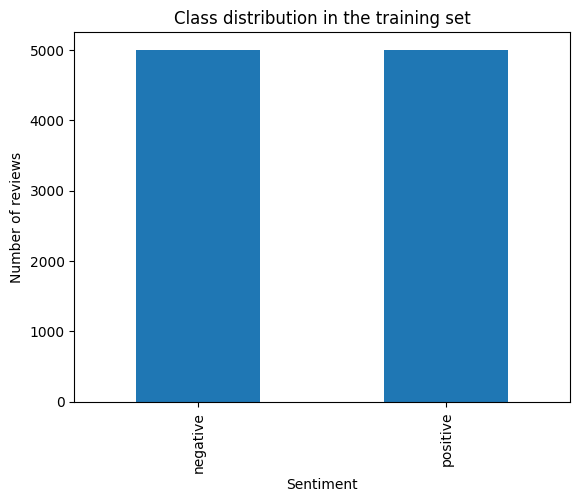

In [ ]:
class_distribution = pd.Series(train_labels).map(label_names).value_counts().sort_index()
print(class_distribution)

class_distribution.plot(kind="bar")
plt.title("Class distribution in the training set")
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.show()

count    10000.000000
mean       233.080500
std        173.257944
min         17.000000
25%        127.000000
50%        174.000000
75%        282.000000
max       2470.000000
dtype: float64


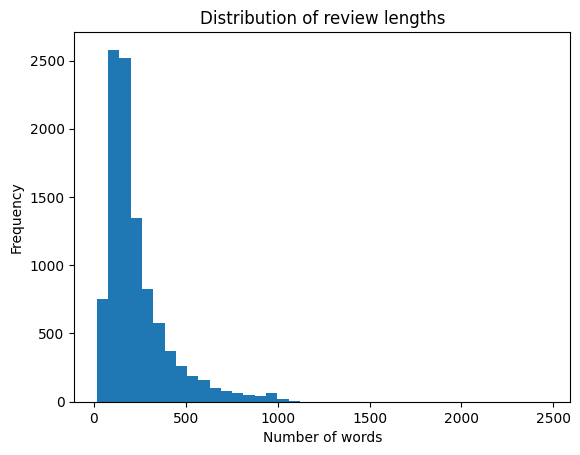

In [ ]:
review_lengths = pd.Series([len(text.split()) for text in train_texts])
print(review_lengths.describe())

review_lengths.plot(kind="hist", bins=40)
plt.title("Distribution of review lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

## 4. Baseline model with TF-IDF and Logistic Regression

A baseline is a simple model used as a first point of comparison. In text classification, TF-IDF with Logistic Regression is often a strong classical baseline.

TF-IDF represents each document according to the relevance of its terms across the corpus. Logistic Regression then learns a decision boundary between negative and positive reviews.

In [ ]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(train_texts)
X_valid_tfidf = tfidf.transform(valid_texts)
X_test_tfidf = tfidf.transform(test_texts)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, train_labels)

baseline_valid_pred = baseline_model.predict(X_valid_tfidf)
baseline_test_pred = baseline_model.predict(X_test_tfidf)

print("Validation accuracy:", accuracy_score(valid_labels, baseline_valid_pred))
print("Test accuracy:", accuracy_score(test_labels, baseline_test_pred))

Validation accuracy: 0.8675
Test accuracy: 0.8666666666666667


In [ ]:
print(classification_report(test_labels, baseline_test_pred, target_names=["negative", "positive"]))

baseline_cm = confusion_matrix(test_labels, baseline_test_pred)
pd.DataFrame(
    baseline_cm,
    index=["Actual negative", "Actual positive"],
    columns=["Predicted negative", "Predicted positive"]
)

              precision    recall  f1-score   support

    negative       0.88      0.85      0.86      1497
    positive       0.86      0.88      0.87      1503

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



,Predicted negative,Predicted positive
Actual negative,1275,222
Actual positive,178,1325


## 5. Text vectorization for neural networks

Neural networks do not process raw text directly. The text must be converted into numerical sequences. The TextVectorization layer builds a vocabulary from the training text and converts each review into a sequence of integer token IDs.

The sequence length is fixed so that the model receives inputs with a consistent shape.

In [ ]:
max_tokens = 20000
sequence_length = 250
batch_size = 64
autotune = tf.data.AUTOTUNE

train_input = tf.constant(train_texts, dtype=tf.string)
valid_input = tf.constant(valid_texts, dtype=tf.string)
test_input = tf.constant(test_texts, dtype=tf.string)

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

adaptation_ds = tf.data.Dataset.from_tensor_slices(train_input).batch(batch_size)
vectorizer.adapt(adaptation_ds)

sample_vector = vectorizer(tf.constant([train_texts[0]], dtype=tf.string))

print(train_texts[0][:300])
print(sample_vector.numpy()[0][:40])

This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda pi
[   11    14    35   435   379    19    88    27  9663     8    33  1249
  3590    40   486 13569   192    24    86   153    18    11   222   314
    27    66   238   217     8   490    55    66    86   112    97    22
  5344    11    91   679]


## 6. Neural model with Embedding and LSTM

The Embedding layer learns a dense vector representation for each token in the vocabulary. The LSTM layer processes the sequence of embeddings and captures order-dependent patterns that can be useful for sentiment classification.

In [ ]:
embedding_dim = 64

lstm_model = tf.keras.Sequential([
    tf.keras.Input(shape=(), dtype=tf.string),
    vectorizer,
    tf.keras.layers.Embedding(input_dim=max_tokens, output_dim=embedding_dim, mask_zero=True),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 250)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 250, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,089 (5.01 MB)

 Trainable params: 1,313,089 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Model training

The model is trained using batched TensorFlow datasets. This format is useful when working with raw text because each review is passed as a string tensor and then processed by the vectorization layer inside the model.

Early stopping monitors the validation loss and restores the best weights found during training.

In [ ]:
train_nn_ds = tf.data.Dataset.from_tensor_slices((train_input, train_labels))
train_nn_ds = train_nn_ds.shuffle(10000, seed=42).batch(batch_size).prefetch(autotune)

valid_nn_ds = tf.data.Dataset.from_tensor_slices((valid_input, valid_labels))
valid_nn_ds = valid_nn_ds.batch(batch_size).prefetch(autotune)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = lstm_model.fit(
    train_nn_ds,
    validation_data=valid_nn_ds,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 186ms/step - accuracy: 0.7045 - loss: 0.5716 - val_accuracy: 0.7935 - val_loss: 0.4450
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 184ms/step - accuracy: 0.8831 - loss: 0.3094 - val_accuracy: 0.8185 - val_loss: 0.4158
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 187ms/step - accuracy: 0.9417 - loss: 0.1718 - val_accuracy: 0.8340 - val_loss: 0.4661
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 187ms/step - accuracy: 0.9677 - loss: 0.1042 - val_accuracy: 0.8310 - val_loss: 0.4704


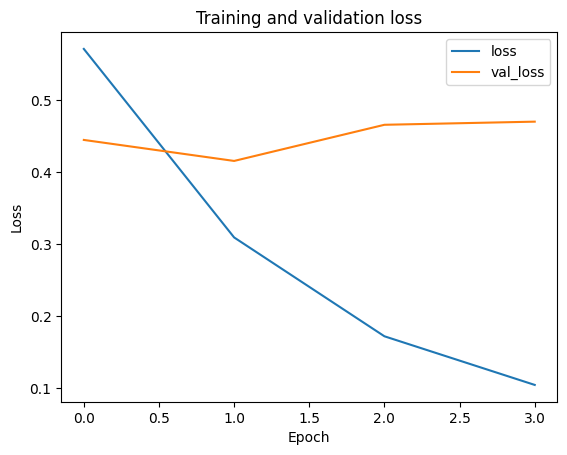

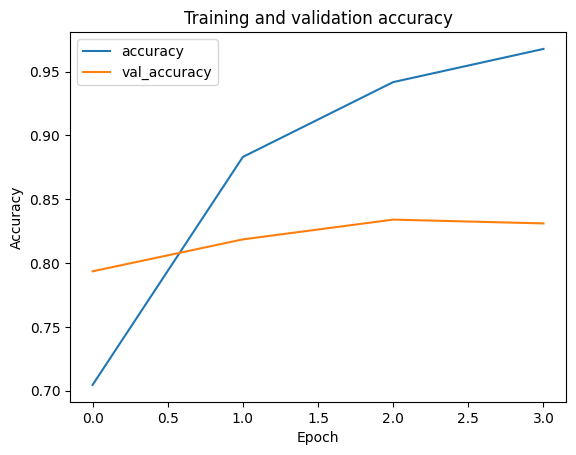

In [ ]:
history_df = pd.DataFrame(history.history)

history_df[["loss", "val_loss"]].plot()
plt.title("Training and validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

history_df[["accuracy", "val_accuracy"]].plot()
plt.title("Training and validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## 8. Model evaluation

The test set is used only after training. The same evaluation metrics used for the baseline are applied to the neural model.

In [ ]:
test_nn_ds = tf.data.Dataset.from_tensor_slices(test_input)
test_nn_ds = test_nn_ds.batch(batch_size).prefetch(autotune)

test_probabilities = lstm_model.predict(test_nn_ds).ravel()
lstm_test_pred = (test_probabilities >= 0.5).astype(int)

print("Test accuracy:", accuracy_score(test_labels, lstm_test_pred))
print(classification_report(test_labels, lstm_test_pred, target_names=["negative", "positive"]))

lstm_cm = confusion_matrix(test_labels, lstm_test_pred)
pd.DataFrame(
    lstm_cm,
    index=["Actual negative", "Actual positive"],
    columns=["Predicted negative", "Predicted positive"]
)

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step
Test accuracy: 0.8336666666666667
              precision    recall  f1-score   support

    negative       0.88      0.77      0.82      1497
    positive       0.80      0.89      0.84      1503

    accuracy                           0.83      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.84      0.83      0.83      3000



,Predicted negative,Predicted positive
Actual negative,1156,341
Actual positive,158,1345


## 9. Compare both models

The baseline and the LSTM model solve the same classification task using different representations. This comparison helps determine whether the additional complexity of the neural model is justified.

In [ ]:
comparison = pd.DataFrame({
    "model": ["TF-IDF + Logistic Regression", "Embedding + LSTM"],
    "test_accuracy": [
        accuracy_score(test_labels, baseline_test_pred),
        accuracy_score(test_labels, lstm_test_pred)
    ]
})

comparison

,model,test_accuracy
0,TF-IDF + Logistic Regression,0.866667
1,Embedding + LSTM,0.833667


## 10. Test with new reviews

After evaluating the model with the test set, it can be applied to new examples. These examples are useful for observing model behavior on clear, ambiguous, or neutral statements.

In [ ]:
new_reviews = [
    "The movie was excellent. The story was emotional and the performances were outstanding.",
    "This was one of the worst films I have ever watched. The plot was boring and confusing.",
    "The movie had some interesting ideas, but the execution was inconsistent.",
    "The film was released in 1999 and it was directed by a well-known director."
]

new_reviews_ds = tf.data.Dataset.from_tensor_slices(tf.constant(new_reviews, dtype=tf.string)).batch(batch_size)
new_probabilities = lstm_model.predict(new_reviews_ds).ravel()

results = pd.DataFrame({
    "review": new_reviews,
    "positive_probability": new_probabilities,
    "predicted_label": [label_names[int(prob >= 0.5)] for prob in new_probabilities]
})

results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


,review,positive_probability,predicted_label
0,The movie was excellent. The story was emotion...,0.918502,positive
1,This was one of the worst films I have ever wa...,0.048126,negative
2,"The movie had some interesting ideas, but the ...",0.166245,negative
3,The film was released in 1999 and it was direc...,0.330152,negative


## 11. Final interpretation

A complete text classification workflow should include data exploration, a baseline model, a more advanced model, and a careful evaluation process. The best model is not always the most complex one. The choice depends on the data, the task, the available resources, and the expected use case.